# Step 1: Dataset Setup
We will load the Edge-IIoTset dataset. Since you have already mounted Google Drive, we will check there first.

In [33]:
import os
from google.colab import drive

# Mount drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/DNN-EdgeIIoT dataset.zip'
local_path = './DNN-EdgeIIoT-dataset.csv'

if os.path.exists(zip_path):
    print(f"✅ Zip found at: {zip_path}")
    print("Extracting dataset...")
    !unzip -o "{zip_path}" -d ./
    print("✅ Dataset extracted successfully.")

In [32]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
file_path = '/content/drive/My Drive/DNN-EdgeIIoT dataset/DNN-EdgeIIoT-dataset.csv'
df = pd.read_csv(file_path, low_memory=False)
print(df.shape)


(2219201, 63)


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

Step 2: Reading the Datasets' CSV file to a Pandas DataFrame:

In [36]:
import pandas as pd
import numpy as np

file_path = 'DNN-EdgeIIoT-dataset.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    print(f"✅ Data loaded successfully. Shape: {df.shape}")
    display(df.head())
else:
    print(f"❌ Error: {file_path} not found. Please ensure the file is available.")

❌ Error: DNN-EdgeIIoT-dataset.csv not found. Please ensure the file is available.


 Step 3 : Exploring some of the DataFrame's contents:

In [37]:
df.head(5)

print(df['Attack_type'].value_counts())

Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


In [38]:
# Checking if the file is ready
import os
print("Files in current folder:", os.listdir())

Files in current folder: ['.config', 'drive', 'sample_data']


Step 4: Dropping data (Columns, duplicated rows, NAN, Null..):

In [39]:
from sklearn.utils import shuffle

drop_columns = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4","arp.dst.proto_ipv4",

         "http.file_data","http.request.full_uri","icmp.transmit_timestamp",

         "http.request.uri.query", "tcp.options","tcp.payload","tcp.srcport",

         "tcp.dstport", "udp.port", "mqtt.msg"]

df.drop(drop_columns, axis=1, inplace=True)

df.dropna(axis=0, how='any', inplace=True)

df.drop_duplicates(subset=None, keep="first", inplace=True)

df = shuffle(df)

df.isna().sum()

print(df['Attack_type'].value_counts())

Attack_type
Normal                   1363998
DDoS_UDP                  121567
DDoS_ICMP                  67939
SQL_injection              50826
DDoS_TCP                   50062
Vulnerability_scanner      50026
Password                   49933
DDoS_HTTP                  48544
Uploading                  36807
Backdoor                   24026
Port_Scanning              19977
XSS                        15066
Ransomware                  9689
Fingerprinting               853
MITM                         358
Name: count, dtype: int64


Step 5: Categorical data encoding (Dummy Encoding):

In [40]:
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn import preprocessing

def encode_text_dummy(df, name):

    dummies = pd.get_dummies(df[name])

    for x in dummies.columns:

        dummy_name = f"{name}-{x}"

        df[dummy_name] = dummies[x]

    df.drop(name, axis=1, inplace=True)

encode_text_dummy(df,'http.request.method')

encode_text_dummy(df,'http.referer')

encode_text_dummy(df,"http.request.version")

encode_text_dummy(df,"dns.qry.name.len")

encode_text_dummy(df,"mqtt.conack.flags")

encode_text_dummy(df,"mqtt.protoname")

encode_text_dummy(df,"mqtt.topic")

Step 6: Creation of the preprocessed dataset

In [41]:
df.to_csv('preprocessed_DNN.csv', encoding='utf-8')

In [42]:
# Loading the preprocessed data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv('preprocessed_DNN.csv')

print("Preprocessed shape:", df.shape)
print("\nAttack types:\n", df['Attack_type'].value_counts())

#   Binary label for intrusion detection
df['label'] = np.where(df['Attack_type'] == 'Normal', 0, 1)

print("\n✅ Binary labels created (0 = Normal, 1 = Attack)")

Preprocessed shape: (1909671, 98)

Attack types:
 Attack_type
Normal                   1363998
DDoS_UDP                  121567
DDoS_ICMP                  67939
SQL_injection              50826
DDoS_TCP                   50062
Vulnerability_scanner      50026
Password                   49933
DDoS_HTTP                  48544
Uploading                  36807
Backdoor                   24026
Port_Scanning              19977
XSS                        15066
Ransomware                  9689
Fingerprinting               853
MITM                         358
Name: count, dtype: int64

✅ Binary labels created (0 = Normal, 1 = Attack)


Splitting the data



In [43]:
# Splitting the data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('preprocessed_DNN.csv')

print("Columns in preprocessed file:", df.columns.tolist())
print("Shape:", df.shape)

# Creating binary label (0 = Normal, 1 = Attack)
df['label'] = np.where(df['Attack_type'] == 'Normal', 0, 1)

# Dropping the original Attack_type column
X = df.drop(columns=['Attack_type', 'label'])
y = df['label']

print("\nFeatures used for training:", X.shape[1])

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("✅ Data ready for model experiments")

Columns in preprocessed file: ['Unnamed: 0', 'arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le', 'icmp.unused', 'http.content_length', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.topic_len', 'mqtt.ver', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id', 'Attack_label', 'Attack_type', 'http.request.method-0', 'http.request.method-0.0', 'http.request.method-GET', 'http.request.method-OPTIONS', 'http.request.method-POST', 'http.request.method-PROPFIND', 'http.request.method-PUT', 'http.request.method-SEARCH', 'http.request.met

Training and comparing multiple models



In [44]:
# Training and comparing multiple models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Models to test
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    "Neural Network": None   # built separately below
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "Neural Network":
        nn_model = Sequential([
            Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        nn_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='binary_crossentropy',
                        metrics=['accuracy'])

        nn_model.fit(X_train, y_train, epochs=10, batch_size=512, verbose=0)
        y_pred = (nn_model.predict(X_test) > 0.5).astype(int).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "Accuracy": round(acc * 100, 2),
        "Report": classification_report(y_test, y_pred, target_names=['Normal', 'Attack'], output_dict=True)
    }

    print(f"{name} Accuracy: {results[name]['Accuracy']}%")

# Show comparison table
summary = pd.DataFrame({name: [results[name]["Accuracy"]] for name in results}).T
summary.columns = ["Accuracy (%)"]
print("\n=== Model Comparison Table ===")
print(summary)


Training Random Forest...
Random Forest Accuracy: 100.0%

Training XGBoost...
XGBoost Accuracy: 100.0%

Training Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11936/11936 ━━━━━━━━━━━━━━━━━━━━ 9s 791us/step
Neural Network Accuracy: 100.0%

=== Model Comparison Table ===
                Accuracy (%)
Random Forest          100.0
XGBoost                100.0
Neural Network         100.0


Training final Neural Network model for report...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 2/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 1.0000 - loss: 5.5187e-05 - val_accuracy: 1.0000 - val_loss: 9.9739e-04
Epoch 3/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 1.0000 - loss: 1.7255e-04 - val_accuracy: 1.0000 - val_loss: 7.9278e-04
Epoch 4/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 1.0000 - loss: 1.4762e-05 - val_accuracy: 1.0000 - val_loss: 9.0036e-04
Epoch 5/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 1.0000 - loss: 7.9847e-05 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 1.0000 - loss: 1.9924e-07 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 1.0000 - loss: 1.3171e-08 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 12s 5

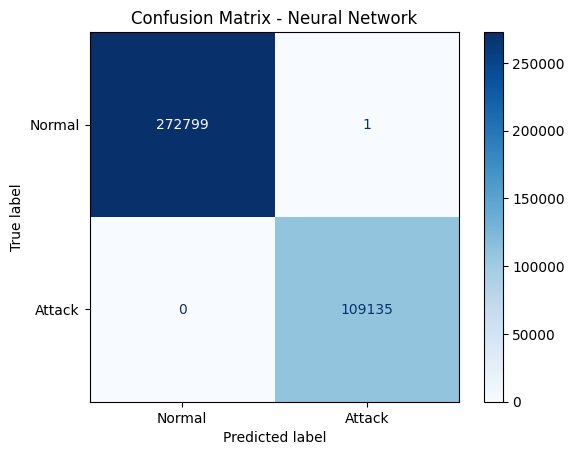

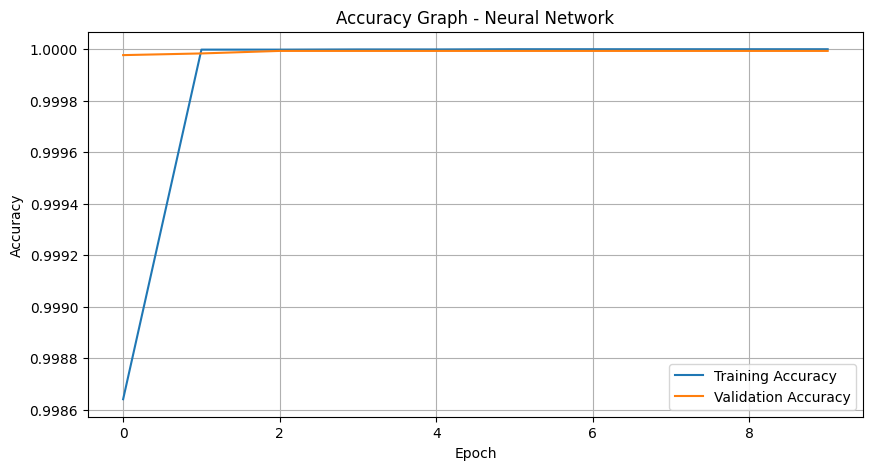

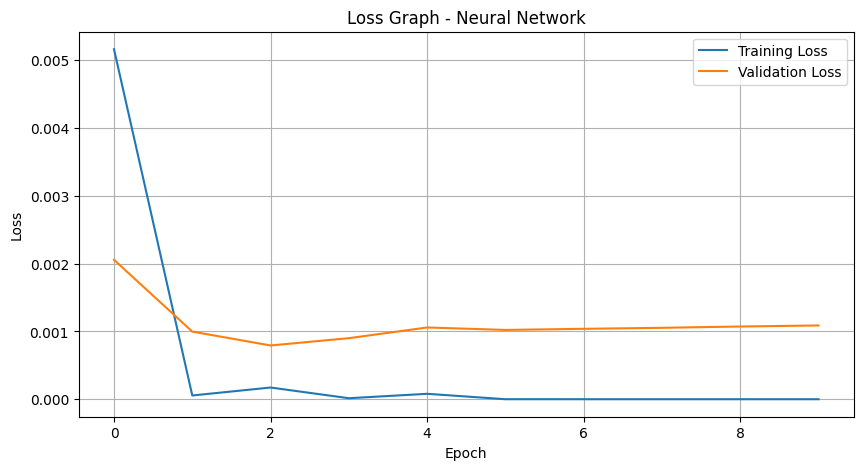


✅ Final model saved as 'final_intrusion_detection_model.h5'
✅ All graphs and metrics generated for the report


In [45]:
# Final Neural Network Model + Full Evaluation for Report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Training final Neural Network model for report...")

# Building and training the model with history to plot graphs
final_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

final_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

history = final_model.fit(X_train, y_train,
                         epochs=10,
                         batch_size=512,
                         validation_split=0.2,
                         verbose=1)

# Predicting on test set
y_pred_nn = (final_model.predict(X_test) > 0.5).astype(int).flatten()

# === 1. Full Evaluation Metrics ===
print("\n=== Final Neural Network Results ===")
print(classification_report(y_test, y_pred_nn, target_names=['Normal', 'Attack']))

# === 2. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.show()

# === 3. Accuracy Graph ===
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph - Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# === 4. Loss Graph ===
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph - Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Save the model for Part B
final_model.save('final_intrusion_detection_model.h5')
print("\n✅ Final model saved as 'final_intrusion_detection_model.h5'")
print("✅ All graphs and metrics generated for the report")

**PART B**

Step 1: Loading requirements for Part B



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# preprocessed data
df = pd.read_csv('preprocessed_DNN.csv')

# Binary labels
df['label'] = np.where(df['Attack_type'] == 'Normal', 0, 1)

# Features and target
X = df.drop(columns=['Attack_type', 'label'])
y = df['label']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split (same as Part A)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data loaded for poisoning experiments")

✅ Data loaded for poisoning experiments


Step 2: Function to create poisoned training labels



In [2]:
# Creating poisoned training labels with an additional method
import numpy as np

def poison_labels(y_train, percentage, strategy="random"):
    # Converting to numpy array
    y_poisoned = y_train.copy().to_numpy()
    n_flips = int(len(y_poisoned) * percentage)

    if strategy == "random":
        # Random flipping (Normal <-> Attack)
        flip_idx = np.random.choice(len(y_poisoned), n_flips, replace=False)
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]

    elif strategy == "targeted":
        # Smart strategy: only flip Attack (1) -> Normal (0) to hide threats
        attack_idx = np.where(y_poisoned == 1)[0]
        if len(attack_idx) >= n_flips:
            flip_idx = np.random.choice(attack_idx, n_flips, replace=False)
            y_poisoned[flip_idx] = 0
        else:
            y_poisoned[attack_idx] = 0

    elif strategy == "noise_injection":
        # New Method: Flip labels of specific high-variance samples
        # This represents a 'boundary attack' where samples are mislabeled to confuse the model
        boundary_idx = np.arange(len(y_poisoned))
        np.random.shuffle(boundary_idx)
        flip_idx = boundary_idx[:n_flips]
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]

    return y_poisoned

Step 3: Running the poisoning experiments



Poisoning: random at 5.0%...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Poisoning: targeted at 5.0%...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Poisoning: noise_injection at 5.0%...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Poisoning: targeted at 30.0%...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Poisoning: noise_injection at 30.0%...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


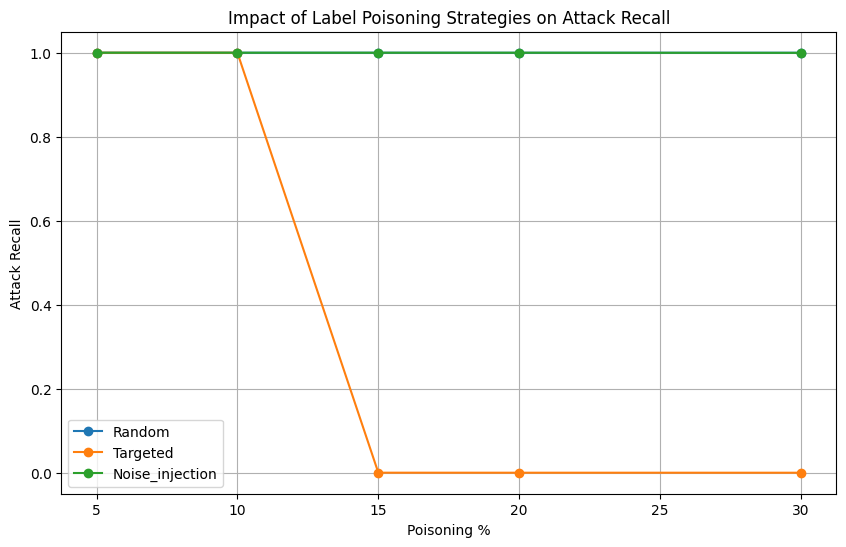

In [3]:
# Running poisoning experiments with the new strategy
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# --- Function Definition to fix NameError ---
def poison_labels(y_train, percentage, strategy="random"):
    y_poisoned = y_train.copy().to_numpy()
    n_flips = int(len(y_poisoned) * percentage)
    if strategy == "random":
        flip_idx = np.random.choice(len(y_poisoned), n_flips, replace=False)
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]
    elif strategy == "targeted":
        attack_idx = np.where(y_poisoned == 1)[0]
        if len(attack_idx) >= n_flips:
            flip_idx = np.random.choice(attack_idx, n_flips, replace=False)
            y_poisoned[flip_idx] = 0
        else:
            y_poisoned[attack_idx] = 0
    elif strategy == "noise_injection":
        boundary_idx = np.arange(len(y_poisoned))
        np.random.shuffle(boundary_idx)
        flip_idx = boundary_idx[:n_flips]
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]
    return y_poisoned

# Correct path based on unzip output
raw_csv_path = './Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv'
processed_csv_path = 'preprocessed_DNN.csv'

# Helper to ensure file exists or create it
if not os.path.exists(processed_csv_path):
    print(f"Processing {raw_csv_path}...")
    if not os.path.exists(raw_csv_path):
        raise FileNotFoundError(f"Could not find dataset at {raw_csv_path}")

    df_raw = pd.read_csv(raw_csv_path, low_memory=False)
    drop_columns = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4","arp.dst.proto_ipv4", "http.file_data","http.request.full_uri","icmp.transmit_timestamp", "http.request.uri.query", "tcp.options","tcp.payload","tcp.srcport", "tcp.dstport", "udp.port", "mqtt.msg"]
    df_raw.drop(columns=[c for c in drop_columns if c in df_raw.columns], inplace=True)
    df_raw.dropna(inplace=True)
    df_raw.drop_duplicates(inplace=True)

    cat_cols = ['http.request.method', 'http.referer', "http.request.version", "dns.qry.name.len", "mqtt.conack.flags", "mqtt.protoname", "mqtt.topic"]
    for col in cat_cols:
        if col in df_raw.columns:
            dummies = pd.get_dummies(df_raw[col], prefix=col)
            df_raw = pd.concat([df_raw, dummies], axis=1)
            df_raw.drop(col, axis=1, inplace=True)
    df_raw.to_csv(processed_csv_path, index=False)

# Loading and splitting
df = pd.read_csv(processed_csv_path)
df['label'] = np.where(df['Attack_type'] == 'Normal', 0, 1)
X = df.drop(columns=['Attack_type', 'label', 'Unnamed: 0'], errors='ignore')
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

percentages = [0.05, 0.10, 0.15, 0.20, 0.30]
strategies = ["random", "targeted", "noise_injection"]
results = {s: [] for s in strategies}

for perc in percentages:
    for strategy in strategies:
        print(f"Poisoning: {strategy} at {perc*100}%...")
        y_p = poison_labels(y_train, perc, strategy)
        model = Sequential([Dense(128, activation='relu', input_shape=(X_train.shape[1],)), Dropout(0.3), Dense(64, activation='relu'), Dropout(0.3), Dense(1, activation='sigmoid')])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_p, epochs=3, batch_size=2048, verbose=0)
        y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
        results[strategy].append(recall_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
for s in strategies: plt.plot([p*100 for p in percentages], results[s], marker='o', label=s.capitalize())
plt.title('Impact of Label Poisoning Strategies on Attack Recall')
plt.xlabel('Poisoning %')
plt.ylabel('Attack Recall')
plt.legend()
plt.grid(True)
plt.show()